# HOMEWORK 2

In [39]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f4c6f862710>)

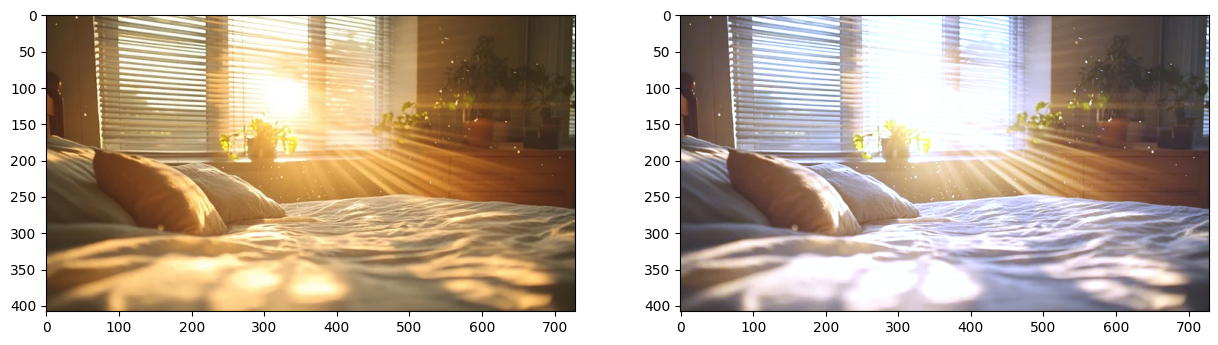

In [40]:
img = plt.imread('data/bedroom.webp')

# Define white patch and the coefficients
row, col = 355, 649
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f4c5fcb1f90>)

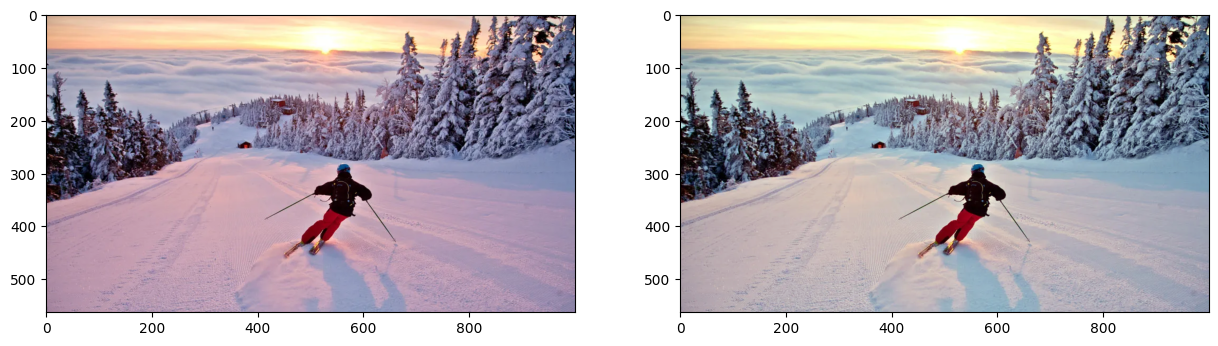

In [41]:
# Load your image
img= plt.imread('data/evening-ski.webp')

# Compute the mean values for all three colour channels (red, green, blue)
split = cv2.split(img)
means = np.array([np.mean(split[ch]) for ch in range(3)])

# Fix the red channel
fixed = 0

# Compute the coefficients kr, kg, kb
coeffs = means[fixed] / means

# Apply color balancing and generate the balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

balanced = balanced/255
balanced[balanced > 1] = 1

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(<Axes: >, <matplotlib.image.AxesImage object at 0x7f4c550f5450>)

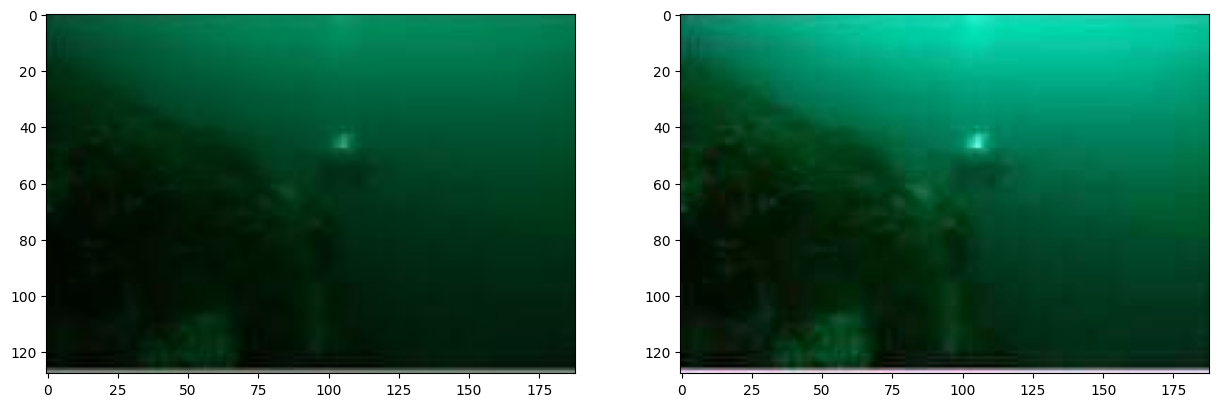

In [42]:
# Load your image
img = plt.imread('data/images.jpeg')

# Compute the maximum values for all three colour channels (red, green, blue)
split = cv2.split(img)
maxes= np.array([np.max(split[ch]) for ch in range(3)])

# Compute the coefficients kr, kg, kb
coeffs = 255 / maxes

# Apply color balancing and generate the balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

## Summary

*Які результати дають різні піксельні операції на різних зображеннях?*

-- усунення "шуму", світлових ефектів, підкреслення деталей за рахунок скейлінгу тьмяних каналів.

*Чому так відбувається?*

-- усе зав'язується на природі математичних операцій. Ha приклад, у алгоритмі gray world ми фіксували канал, колір якого переважає на зображенні і ділячи середнє значення такого на середнє іншого каналу, отримаємо коефіціент підсилення каналу > 1

*На яких зображеннях на вашу думку, яку піксельну операцію краще застосовувати?*

* white patch, де зображення містить який об'єкт, що у дійсності є білим. Операція допомагає якраз таки відновити білизну такого і цим самим ефект світла усувається по всьому зображеннi

* gray world, де переважає якийсь один канал, і можна б зарахунок підсилення інших зробити зображення кращим

* scale-by-max, де зображення потребує насичення -- операція маштабує кожен канал до максимального значення
